In [ ]:
import pandas as pd
from pathlib import Path

file_path = Path("C:\Users\Apurva Singh\Documents\SUBJECTS\Term IV\Data Science and Machine Learning\Session 2\example data.csv")
df = pd.read_csv(file_path)
df.head()

,Year,Prod_Description (SKU),Payment_Mode,Order_Number,Order_Value,Order_Status,Street_Name,City,State,Pin_Code,Contact_Number,Tracking_ID,Customer_Type,Multiple_Item,Class_RWOD
0,2021,SHO-M-BLK-XL-LT,Pre-Paid,ORD202101001,"?3,022.43",Returned-Undelivered,Anna Salai 216,Jaipur,Rajasthan,NaN,9.836365e+09,77276847,New,1,1
1,2021,SRE-U-WHT-M-HV,COD,ORD202101002,"?3,933.92",Delivered,Linking Rd 170,Coimbatore,Tamil Nadu,574925.0,7.439297e+09,EZ361992,Existing,0,0
2,2021,TSH-U-GRN-XL-MD,Pre-Paid,ORD202101003,"?5,315.09",Delivered,Sector 15 206,Ludhiana,Punjab,717952.0,8.288484e+09,EZ130813,Existing,0,0
3,2021,JNS-F-WHT-XS-HV,COD,ORD202101004,"?1,058.37",Delivered,Rajaji Nagar 172,Ludhiana,Punjab,485321.0,9.456559e+09,85387117,Existing,0,0
4,2021,WAT-U-GRN-XL-MD,COD,ORD202101005,"?4,253.87",Returned-Undelivered,FC Road 124,Kolkata,West Bengal,394897.0,6.912476e+09,53640209,Existing,0,1


In [ ]:
# Create a boolean mask identifying all rows with "Returned-Undelivered" status
returned_mask = df["Order_Status"].str.contains("Returned-Undelivered", case=False, na=False)

# Group data by Multiple_Item column and calculate aggregate statistics
group = df.groupby("Multiple_Item").agg(
    # Count total number of orders in each group
    total_orders=("Order_Status", "size"),
    # Count orders with "Returned-Undelivered" status in each group using custom lambda function
    returned_orders=("Order_Status", lambda x: x.str.contains("Returned-Undelivered", case=False, na=False).sum())
)

# Calculate return rate as a percentage for each group
group["return_rate_pct"] = group["returned_orders"] / group["total_orders"] * 100

# Extract return rate for single-item orders (group index 0)
single_rate = group.loc[0, "return_rate_pct"]
# Extract return rate for multiple-item orders (group index 1)
multi_rate = group.loc[1, "return_rate_pct"]
# Calculate percentage change from single-item to multiple-item return rate
pct_change = (multi_rate - single_rate) / single_rate * 100

# Display the complete grouped summary table
print(group)
# Display single-item order return rate
print(f"\nSingle item return rate: {single_rate:.2f}%")
# Display multiple-item order return rate
print(f"Multiple item return rate: {multi_rate:.2f}%")
# Display percentage change between the two return rates
print(f"Percentage change from single to multiple: {pct_change:.2f}%")

               total_orders  returned_orders  return_rate_pct
Multiple_Item                                                
0                       422               92        21.800948
1                       178               35        19.662921

Single item return rate: 21.80%
Multiple item return rate: 19.66%
Percentage change from single to multiple: -9.81%


In [ ]:
# Create a new column 'MOP' based on 'payment_mode' column
# Value is 1 if payment mode is 'pre-paid', 0 otherwise
df['MOP'] = (df['Payment_Mode'].str.lower().fillna('') == 'pre-paid').astype(int)

# Display the first few rows to verify the new column
df.head()

,Year,Prod_Description (SKU),Payment_Mode,Order_Number,Order_Value,Order_Status,Street_Name,City,State,Pin_Code,Contact_Number,Tracking_ID,Customer_Type,Multiple_Item,Class_RWOD,MOP
0,2021,SHO-M-BLK-XL-LT,Pre-Paid,ORD202101001,"?3,022.43",Returned-Undelivered,Anna Salai 216,Jaipur,Rajasthan,NaN,9.836365e+09,77276847,New,1,1,1
1,2021,SRE-U-WHT-M-HV,COD,ORD202101002,"?3,933.92",Delivered,Linking Rd 170,Coimbatore,Tamil Nadu,574925.0,7.439297e+09,EZ361992,Existing,0,0,0
2,2021,TSH-U-GRN-XL-MD,Pre-Paid,ORD202101003,"?5,315.09",Delivered,Sector 15 206,Ludhiana,Punjab,717952.0,8.288484e+09,EZ130813,Existing,0,0,1
3,2021,JNS-F-WHT-XS-HV,COD,ORD202101004,"?1,058.37",Delivered,Rajaji Nagar 172,Ludhiana,Punjab,485321.0,9.456559e+09,85387117,Existing,0,0,0
4,2021,WAT-U-GRN-XL-MD,COD,ORD202101005,"?4,253.87",Returned-Undelivered,FC Road 124,Kolkata,West Bengal,394897.0,6.912476e+09,53640209,Existing,0,1,0


In [5]:
# Create a new column 'PIN' based on 'Pin_Code' column
# Value is 1 if Pin_Code is present (not null), 0 if it is null
df['PIN'] = df['Pin_Code'].notna().astype(int)

# Display the first few rows to verify the new column
df.head()

,Year,Prod_Description (SKU),Payment_Mode,Order_Number,Order_Value,Order_Status,Street_Name,City,State,Pin_Code,Contact_Number,Tracking_ID,Customer_Type,Multiple_Item,Class_RWOD,MOP,PIN
0,2021,SHO-M-BLK-XL-LT,Pre-Paid,ORD202101001,"?3,022.43",Returned-Undelivered,Anna Salai 216,Jaipur,Rajasthan,NaN,9.836365e+09,77276847,New,1,1,1,0
1,2021,SRE-U-WHT-M-HV,COD,ORD202101002,"?3,933.92",Delivered,Linking Rd 170,Coimbatore,Tamil Nadu,574925.0,7.439297e+09,EZ361992,Existing,0,0,0,1
2,2021,TSH-U-GRN-XL-MD,Pre-Paid,ORD202101003,"?5,315.09",Delivered,Sector 15 206,Ludhiana,Punjab,717952.0,8.288484e+09,EZ130813,Existing,0,0,1,1
3,2021,JNS-F-WHT-XS-HV,COD,ORD202101004,"?1,058.37",Delivered,Rajaji Nagar 172,Ludhiana,Punjab,485321.0,9.456559e+09,85387117,Existing,0,0,0,1
4,2021,WAT-U-GRN-XL-MD,COD,ORD202101005,"?4,253.87",Returned-Undelivered,FC Road 124,Kolkata,West Bengal,394897.0,6.912476e+09,53640209,Existing,0,1,0,1


In [6]:
df['CUStype'] = (df['Customer_Type'].str.lower().fillna('') == 'new').astype(int)

# Display the first few rows to verify the new column
df.head()

,Year,Prod_Description (SKU),Payment_Mode,Order_Number,Order_Value,Order_Status,Street_Name,City,State,Pin_Code,Contact_Number,Tracking_ID,Customer_Type,Multiple_Item,Class_RWOD,MOP,PIN,CUStype
0,2021,SHO-M-BLK-XL-LT,Pre-Paid,ORD202101001,"?3,022.43",Returned-Undelivered,Anna Salai 216,Jaipur,Rajasthan,NaN,9.836365e+09,77276847,New,1,1,1,0,1
1,2021,SRE-U-WHT-M-HV,COD,ORD202101002,"?3,933.92",Delivered,Linking Rd 170,Coimbatore,Tamil Nadu,574925.0,7.439297e+09,EZ361992,Existing,0,0,0,1,0
2,2021,TSH-U-GRN-XL-MD,Pre-Paid,ORD202101003,"?5,315.09",Delivered,Sector 15 206,Ludhiana,Punjab,717952.0,8.288484e+09,EZ130813,Existing,0,0,1,1,0
3,2021,JNS-F-WHT-XS-HV,COD,ORD202101004,"?1,058.37",Delivered,Rajaji Nagar 172,Ludhiana,Punjab,485321.0,9.456559e+09,85387117,Existing,0,0,0,1,0
4,2021,WAT-U-GRN-XL-MD,COD,ORD202101005,"?4,253.87",Returned-Undelivered,FC Road 124,Kolkata,West Bengal,394897.0,6.912476e+09,53640209,Existing,0,1,0,1,0


In [7]:
# Create a new column 'Contact' based on 'Pin_Code' column
# Value is 1 if Pin_Code is present (not null), 0 if it is null
df['Contact'] = df['Contact_Number'].notna().astype(int)

# Display the first few rows to verify the new column
df.head()

,Year,Prod_Description (SKU),Payment_Mode,Order_Number,Order_Value,Order_Status,Street_Name,City,State,Pin_Code,Contact_Number,Tracking_ID,Customer_Type,Multiple_Item,Class_RWOD,MOP,PIN,CUStype,Contact
0,2021,SHO-M-BLK-XL-LT,Pre-Paid,ORD202101001,"?3,022.43",Returned-Undelivered,Anna Salai 216,Jaipur,Rajasthan,NaN,9.836365e+09,77276847,New,1,1,1,0,1,1
1,2021,SRE-U-WHT-M-HV,COD,ORD202101002,"?3,933.92",Delivered,Linking Rd 170,Coimbatore,Tamil Nadu,574925.0,7.439297e+09,EZ361992,Existing,0,0,0,1,0,1
2,2021,TSH-U-GRN-XL-MD,Pre-Paid,ORD202101003,"?5,315.09",Delivered,Sector 15 206,Ludhiana,Punjab,717952.0,8.288484e+09,EZ130813,Existing,0,0,1,1,0,1
3,2021,JNS-F-WHT-XS-HV,COD,ORD202101004,"?1,058.37",Delivered,Rajaji Nagar 172,Ludhiana,Punjab,485321.0,9.456559e+09,85387117,Existing,0,0,0,1,0,1
4,2021,WAT-U-GRN-XL-MD,COD,ORD202101005,"?4,253.87",Returned-Undelivered,FC Road 124,Kolkata,West Bengal,394897.0,6.912476e+09,53640209,Existing,0,1,0,1,0,1


Background dataset has 450 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=450 when initializing the masker.


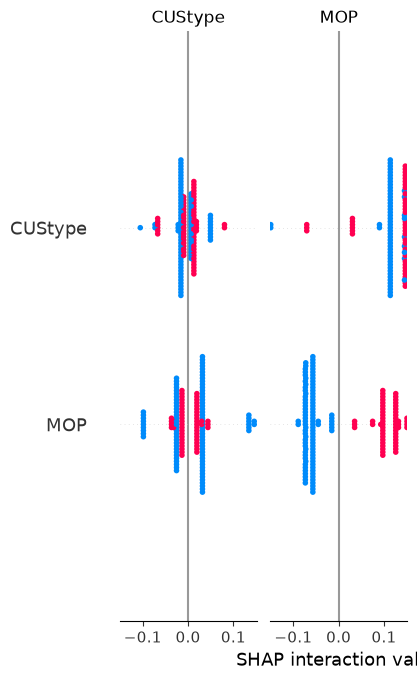

In [11]:
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Select features and prepare target variable
X = df[['MOP', 'CUStype', 'PIN', 'Contact']].astype(int)
y = df['Class_RWOD']

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Create SHAP explainer and calculate SHAP values
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Create SHAP summary plot showing feature importance with colored dots
# Blue dots = low feature values, Red dots = high feature values
# Horizontal position shows impact on model output
shap.summary_plot(shap_values, X_test, plot_type='dot')

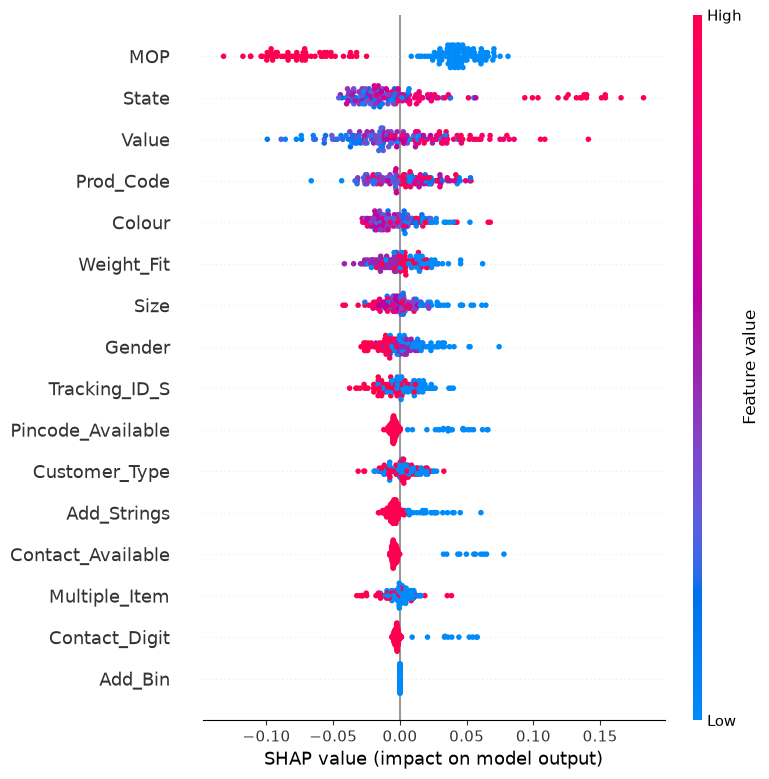

In [13]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# ── Parse SKU: PROD-GENDER-COLOUR-SIZE-WEIGHTFIT ──────────────────────
sku = df['Prod_Description (SKU)'].str.split('-', expand=True)
sku.columns = ['_Prod', '_Gender', '_Colour', '_Size', '_WF']

df['Prod_Code']   = le.fit_transform(sku['_Prod'].fillna('UNK'))
df['Gender']      = le.fit_transform(sku['_Gender'].fillna('U'))
df['Colour']      = le.fit_transform(sku['_Colour'].fillna('UNK'))
df['Size']        = le.fit_transform(sku['_Size'].fillna('UNK'))
df['Weight_Fit']  = le.fit_transform(sku['_WF'].fillna('UNK'))

# ── Additional features ───────────────────────────────────────────────
# Tracking_ID_S: 1 if ID starts with letters (EZ...), 0 if purely numeric
df['Tracking_ID_S'] = df['Tracking_ID'].astype(str).str.match(r'^[A-Za-z]').astype(int)

# Value: numeric order value (strip currency symbol and commas)
df['Value'] = pd.to_numeric(
    df['Order_Value'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
).fillna(0)

# State: label-encoded
df['State_enc'] = le.fit_transform(df['State'].fillna('Unknown'))

# Add_Strings: word count in street address
df['Add_Strings'] = df['Street_Name'].fillna('').str.split().apply(len)

# Add_Bin: 1 if street address contains a digit
df['Add_Bin'] = df['Street_Name'].fillna('').str.contains(r'\d', regex=True).astype(int)

# Contact_Digit: digit-count of contact number (0 if missing)
df['Contact_Digit'] = df['Contact_Number'].apply(
    lambda x: len(str(int(x))) if pd.notna(x) else 0
)

# Pincode_Available & Contact_Available (binary)
df['Pincode_Available'] = df['Pin_Code'].notna().astype(int)
df['Contact_Available'] = df['Contact_Number'].notna().astype(int)

# ── Assemble feature matrix ───────────────────────────────────────────
feature_map = {
    'MOP':               'MOP',
    'Customer_Type':     'CUStype',
    'Tracking_ID_S':     'Tracking_ID_S',
    'Add_Strings':       'Add_Strings',
    'Contact_Digit':     'Contact_Digit',
    'Value':             'Value',
    'State':             'State_enc',
    'Add_Bin':           'Add_Bin',
    'Prod_Code':         'Prod_Code',
    'Contact_Available': 'Contact_Available',
    'Size':              'Size',
    'Colour':            'Colour',
    'Gender':            'Gender',
    'Weight_Fit':        'Weight_Fit',
    'Pincode_Available': 'Pincode_Available',
    'Multiple_Item':     'Multiple_Item',
}

X = df[[v for v in feature_map.values()]].copy().fillna(0)
X.columns = list(feature_map.keys())   # rename to display names
y = df['Class_RWOD']

# ── Train model ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y
)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ── SHAP beeswarm plot ────────────────────────────────────────────────
explainer   = shap.TreeExplainer(model)
shap_vals   = explainer(X_test)

# For binary classification TreeExplainer returns shape (n, features, 2); pick class-1
sv = shap_vals[:, :, 1] if shap_vals.values.ndim == 3 else shap_vals

shap.summary_plot(sv, X_test, plot_type='dot', show=True)


In [14]:
df.head

<bound method NDFrame.head of      Year Prod_Description (SKU) Payment_Mode  Order_Number Order_Value  \
0    2021        SHO-M-BLK-XL-LT     Pre-Paid  ORD202101001   ?3,022.43   
1    2021         SRE-U-WHT-M-HV          COD  ORD202101002   ?3,933.92   
2    2021        TSH-U-GRN-XL-MD     Pre-Paid  ORD202101003   ?5,315.09   
3    2021        JNS-F-WHT-XS-HV          COD  ORD202101004   ?1,058.37   
4    2021        WAT-U-GRN-XL-MD          COD  ORD202101005   ?4,253.87   
..    ...                    ...          ...           ...         ...   
595  2021         JNS-F-BLK-S-HV     Pre-Paid  ORD202101596   ?5,371.91   
596  2021       DRS-U-PNK-XXL-MD     Pre-Paid  ORD202101597   ?1,605.99   
597  2021         WAT-F-GRY-L-HV          COD  ORD202101598     ?446.41   
598  2021        SRE-F-BLK-XS-HV          COD  ORD202101599   ?3,973.27   
599  2021        DRS-F-GRY-XS-HV          COD  ORD202101600   ?1,055.32   

             Order_Status       Street_Name        City        State 